### Basic Anomaly Detection (tensorflow version)) of Financial Time Series Data using an Autoencoder
References:
- [Susan Li, "Time Series of Price Anomaly Detection with LSTM" in Medium 2020](https://medium.com/data-science/time-series-of-price-anomaly-detection-with-lstm-11a12ba4f6d9)
- [DigitalSreeni, "180 - LSTM Autoencoder for anomaly detection", Youtube Video](https://www.youtube.com/watch?v=6S2v7G-OupA)

### Imports

In [2]:
import numpy as np
import yfinance as yf
from tensorflow import keras
from keras.models import Sequential
from keras.layers import LSTM, Input, Dropout
from keras.layers import Dense
from keras.layers import RepeatVector
from keras.layers import TimeDistributed
import pandas as pd
from matplotlib import pyplot as plt
import plotly.graph_objects as go
from sklearn.preprocessing import MinMaxScaler, StandardScaler
from keras.models import Model
import seaborn as sns
from dataclasses import dataclass
from enum import Enum
from typing import Tuple

%matplotlib inline

### Define Configurations

In [3]:
TOP_10_TECH_TICKERS = ["NVDA","AAPL","GOOGL", "MSFT", "AMZN", "TSM", "AVGO", "META", "TSLA", "ASML"]

@dataclass
class Config:
    ticker: str = 'GE'
    start_date: str = '2015-03-11'
    end_date: str = '2025-03-11'
    covidemic_start_date: str = '2020-03-11'
    validation_factor: float = 0.2
    sequence_length: int = 30
    hidden_dim_1: int = 64
    hidden_dim_2: int = 32
    latent_dim: int = 4
    batch_size: int = 32
    num_epochs: int = 50
    learning_rate: float = 0.001
    
config = Config()

### Define enums

In [4]:
class ThresholdMethod(Enum):
    MAX = 'max'
    PERCENTILE_90 = 'percentile_90'
    THREE_SIGMA = 'three_sigma'

### Data processing:
- Get the data
- Scale the data
- Create data moving window

In [5]:
def load_data(ticker: str, start_date: str, end_date: str) -> np.ndarray:
    """
    Load historical stock price data for a given ticker and date range.
    :param ticker: Stock ticker symbol (e.g., 'AAPL' for Apple Inc.)
    :param start_date: Start date for data in 'YYYY-MM-DD' format   
    :param end_date: End date for data in 'YYYY-MM-DD' format
    :return: Numpy array of closing prices   
    """
    data_df = yf.download(ticker, start=start_date, end=end_date)
    return data_df['Close'].values.reshape(-1, 1), data_df

def split_train_test(data_df: pd.DataFrame, split_date: str):
    """
    Split the data into training and testing sets based on a specified date.
    :param data_df: DataFrame containing the stock price data
    :param split_date: Date to split the data into training and testing sets
    :return: Tuple of (training data, testing data)
    """
    split_idx = data_df.index.get_loc(pd.Timestamp(split_date))
    prices = data_df['Close'].values.reshape(-1, 1)
    train_data = prices[:split_idx]
    test_data = prices[split_idx:]
    return train_data, test_data

def scale_data(train_data: np.ndarray, test_data: np.ndarray):
    """
    Scale training and testing data using MinMaxScaler fitted on training data.
    :param train_data: Training data array
    :param test_data: Testing data array
    :return: Tuple of (scaled training data, scaled testing data, fitted scaler)
    """
    scaler = MinMaxScaler()
    train_scaled = scaler.fit_transform(train_data)
    test_scaled = scaler.transform(test_data)
    return train_scaled, test_scaled, scaler

def create_sequences(data: np.ndarray, seq_len: int = config.sequence_length) -> np.ndarray:
    """Create sequences of data for training the model.
    :param data: Numpy array of scaled data
    :param seq_len: Length of each sequence
    :return: Numpy array of sequences
    """
    sequences = []
    for i in range(len(data) - seq_len):
        sequences.append(data[i:i+seq_len])
    return np.array(sequences)


def preprocess_data(data: np.ndarray, sequence_length: int) -> (np.ndarray, MinMaxScaler):
    """
    Preprocess the data by normalizing and creating sequences.
    :param data: Numpy array of closing prices
    :param sequence_length: Length of each input sequence for the model
    :return: Tuple of (input sequences as torch.Tensor, fitted MinMaxScaler)
    """
    scaler = MinMaxScaler()
    scaled_data = scaler.fit_transform(data)
    
    sequences = []
    for i in range(len(scaled_data) - sequence_length):
        sequences.append(scaled_data[i:i+sequence_length])
    
    return sequences, scaler

In [6]:
data, data_df = load_data(config.ticker, config.start_date, config.end_date)
train_data, test_data = split_train_test(data_df, config.covidemic_start_date)
train_scaled, test_scaled, scaler = scale_data(train_data, test_data) 
X_train = create_sequences(train_scaled, config.sequence_length)
X_test = create_sequences(test_scaled, config.sequence_length)

data_df.head()

C:\Users\adeid\AppData\Local\Temp\ipykernel_18176\436041787.py:9: FutureWarning: YF.download() has changed argument auto_adjust default to True
  data_df = yf.download(ticker, start=start_date, end=end_date)
[*********************100%***********************]  1 of 1 completed


Price,Close,High,Low,Open,Volume
Ticker,GE,GE,GE,GE,GE
Date,,,,,
2015-03-11,103.908569,105.146065,103.702318,104.279819,7553171
2015-03-12,104.774803,104.816056,103.826058,104.238561,6128301
2015-03-13,103.289810,104.609805,102.341059,104.279808,9453853
2015-03-16,104.981041,105.104793,102.959799,103.372295,7221878
2015-03-17,104.403542,104.733539,103.496043,104.362289,7148555


In [7]:
X_train.shape

(1229, 30, 1)

### Define Autoencoder
- An autoencoder is composed of an encoder / decoder blocks and a middle latent ("bottleneck") dimension layer
- Due to the time-series nature of our data set the autoencoder encoder/decoder blocks  will be consist of LSTM layers

In [8]:
class LSTMAutoencoder:
    def __init__(self, config: Config): 
        self.config = config
        self.model = self.build_model()
    
    def build_model(self) -> Model:
        """
        Build the LSTM Autoencoder model architecture.
        :return: Compiled Keras Model
        """
        model = Sequential()
        model.add(LSTM(self.config.hidden_dim_1, activation='relu', input_shape=(X_train.shape[1], X_train.shape[2]), return_sequences=True))
        model.add(Dropout(0.2))
        model.add(LSTM(self.config.hidden_dim_2, activation='relu', return_sequences=False))
        model.add(Dropout(0.2))
        model.add(RepeatVector(self.config.sequence_length))
        model.add(LSTM(self.config.hidden_dim_2, activation='relu', return_sequences=True))
        model.add(Dropout(0.2))
        model.add(LSTM(self.config.hidden_dim_1, activation='relu', return_sequences=True))
        model.add(Dropout(0.2))
        model.add(TimeDistributed(Dense(1)))
        
        model.compile(optimizer='adam', loss='mae')
        return model

    

### Specify the Anomaly Detector

In [9]:
class AnomalyDetector:
    """
    Anomaly Detector based on a LSTM-Autoencoder model
    """
    def __init__(
        self, 
        config: Config, 
        X_train: np.ndarray, 
        X_test: np.ndarray):
        """
        Initialize the AnomalyDetector with the given configuration.
        :param config: Config object containing hyperparameters such as sequence length, hidden dimensions, latent dimension, batch size, number of epochs, and learning rate.
        """
        self.config = config
        self.autoencoder = LSTMAutoencoder(config)
        self.X_train = X_train
        self.X_test = X_test
        self.callbacks=[keras.callbacks.EarlyStopping(monitor='val_loss', patience=15, mode='min')]

    def fit(self):
        """
        Train the LSTM Autoencoder model on the training data.
        :param X_train: Numpy array of training sequences
        """
        history = self.autoencoder.model.fit(
            self.X_train, 
            self.X_train, 
            epochs=self.config.num_epochs, 
            batch_size=self.config.batch_size, 
            validation_split=self.config.validation_factor, 
            callbacks=self.callbacks,
            shuffle=False,
            verbose=1)
        plt.plot(history.history['loss'], label='Training loss')
        plt.plot(history.history['val_loss'], label='Validation loss')
        plt.legend()

    def predict(self, threshold_method: ThresholdMethod = ThresholdMethod.PERCENTILE_90) -> Tuple[np.ndarray, np.ndarray, np.ndarray, float]:
        """
        Use the trained model to reconstruct the input sequences and calculate reconstruction errors.
        :param X: Numpy array of input sequences to predict
        :return: Numpy array of reconstruction errors for each sequence
        """
        y_train_hat = self.autoencoder.model.predict(self.X_train)
        train_mae = np.mean(np.abs(y_train_hat - self.X_train), axis=1)        
        max_train_mae = np.max(train_mae)  #or Define 90% value of max as threshold.
        percentile_90 = np.percentile(train_mae, 90)
        three_sigma_threshold = np.mean(train_mae) + 3 * np.std(train_mae)
        print(f"Max Train MAE: {max_train_mae}, 90th Percentile Train MAE: {percentile_90}, Three-Sigma Threshold: {three_sigma_threshold}")

        y_test_hat = self.autoencoder.model.predict(self.X_test)
        test_mae = np.mean(np.abs(y_test_hat - self.X_test), axis=1)
        
        match threshold_method:
            case ThresholdMethod.MAX:
                threshold = max_train_mae
            case ThresholdMethod.PERCENTILE_90:
                threshold = percentile_90
            case ThresholdMethod.THREE_SIGMA:
                threshold = three_sigma_threshold
            case _:
                raise ValueError(f"Unsupported threshold method: {threshold_method}")

        predicted_anomalies = test_mae > threshold

        fig, axes = plt.subplots(2, 1, figsize=(8, 8))
        axes[0].hist(train_mae, bins=10, color='blue', alpha=0.7)
        axes[0].set_title('Training MAE Histogram')
        axes[0].set_xlabel('MAE')
        axes[0].set_ylabel('Frequency')

        axes[1].hist(test_mae, bins=10, color='orange', alpha=0.7)
        axes[1].set_title('Test MAE Histogram')
        axes[1].set_xlabel('MAE')
        axes[1].set_ylabel('Frequency')

        fig.tight_layout()
        plt.show()
        
        return train_mae, test_mae, predicted_anomalies, threshold

c:\Users\adeid\miniconda3\envs\ai-thursdays-env\Lib\site-packages\keras\src\layers\rnn\rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Epoch 1/50
31/31 ━━━━━━━━━━━━━━━━━━━━ 6s 51ms/step - loss: 0.4337 - val_loss: 0.0505
Epoch 2/50
31/31 ━━━━━━━━━━━━━━━━━━━━ 1s 30ms/step - loss: 0.3802 - val_loss: 0.0952
Epoch 3/50
31/31 ━━━━━━━━━━━━━━━━━━━━ 1s 29ms/step - loss: 0.2578 - val_loss: 0.0685
Epoch 4/50
31/31 ━━━━━━━━━━━━━━━━━━━━ 1s 30ms/step - loss: 0.2874 - val_loss: 0.0726
Epoch 5/50
31/31 ━━━━━━━━━━━━━━━━━━━━ 1s 30ms/step - loss: 0.2322 - val_loss: 0.0538
Epoch 6/50
31/31 ━━━━━━━━━━━━━━━━━━━━ 1s 30ms/step - loss: 0.2029 - val_loss: 0.0644
Epoch 7/50
31/31 ━━━━━━━━━━━━━━━━━━━━ 1s 31ms/step - loss: 0.1390 - val_loss: 0.0452
Epoch 8/50
31/31 ━━━━━━━━━━━━━━━━━━━━ 1s 30ms/step - loss: 0.1642 - val_loss: 0.0537
Epoch 9/50
31/31 ━━━━━━━━━━━━━━━━━━━━ 1s 30ms/step - loss: 0.1334 - val_loss: 0.0355
Epoch 10/50
31/31 ━━━━━━━━━━━━━━━━━━━━ 1s 30ms/step - loss: 0.1594 - val_loss: 0.0341
Epoch 11/50
31/31 ━━━━━━━━━━━━━━━━━━━━ 1s 31ms/step - loss: 0.1638 - val_loss: 0.0402
Epoch 12/50
31/31 ━━━━━━━━━━━━━━━━━━━━ 1s 31ms/step - loss: 0.1

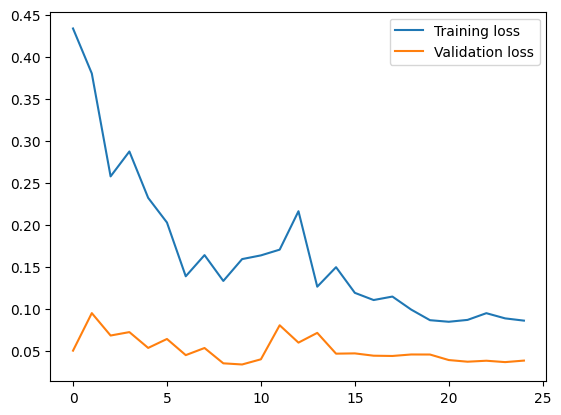

In [10]:
detector = AnomalyDetector(config, X_train, X_test)
detector.fit()  


39/39 ━━━━━━━━━━━━━━━━━━━━ 1s 24ms/step
Max Train MAE: 0.15170949680976697, 90th Percentile Train MAE: 0.12032035102838914, Three-Sigma Threshold: 0.1766156223209632
39/39 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step


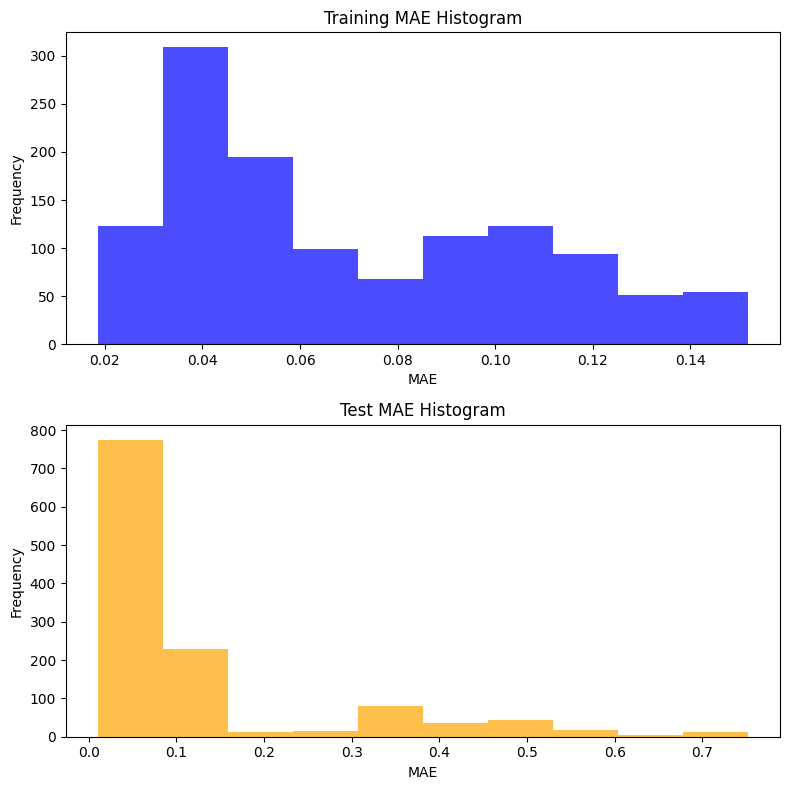

In [11]:
train_mae, test_mae, predicted_anomalies, threshold = detector.predict()

### Analysis of the predicted anomalies

In [12]:
def visualize_anomalies(
    X_test: np.ndarray,
    test_mae: np.ndarray, 
    predicted_anomalies: np.ndarray, 
    threshold: float,
    config: Config):
    """
    Visualize the distribution of reconstruction errors and highlight the detected anomalies.
    :param test_mae: Numpy array of reconstruction errors for the test set
    :param predicted_anomalies: Numpy array of boolean values indicating which sequences are predicted as anomalies
    :param threshold: The threshold used to identify anomalies
    :param config: Config object containing the original data and date information for plotting
    """
    test_data_df = data_df.copy()
    test_data_df['Date'] = test_data_df.index
    filter_start_date = pd.to_datetime(config.covidemic_start_date)
    test_data_score_df = test_data_df[test_data_df['Date'] >= filter_start_date]
    test_data_score_df = test_data_score_df.reset_index(drop=True)
    selected_test_data_score_df = test_data_score_df.iloc[config.sequence_length:]
    selected_test_data_score_df['loss'] = test_mae
    selected_test_data_score_df['threshold'] = threshold
    selected_test_data_score_df['anomaly'] = selected_test_data_score_df['loss'] > selected_test_data_score_df['threshold']    

    fig = go.Figure()
    fig.add_trace(go.Scatter(x=selected_test_data_score_df['Date'], y=selected_test_data_score_df['loss'], name='Test loss'))
    fig.add_trace(go.Scatter(x=selected_test_data_score_df['Date'], y=selected_test_data_score_df['threshold'], name='Threshold'))
    fig.update_layout(showlegend=True, title='Test loss vs. Threshold')
    fig.show()
    

In [13]:
visualize_anomalies(X_test, test_mae, predicted_anomalies, threshold, config)

C:\Users\adeid\AppData\Local\Temp\ipykernel_18176\2747336968.py:20: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  selected_test_data_score_df['loss'] = test_mae
C:\Users\adeid\AppData\Local\Temp\ipykernel_18176\2747336968.py:21: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  selected_test_data_score_df['threshold'] = threshold
C:\Users\adeid\AppData\Local\Temp\ipykernel_18176\2747336968.py:22: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_index

In [14]:
print("X_test shape:", X_test.shape)
print("test_mae shape:", test_mae.shape)
print(f"test_data_score_df shape: {test_data_score_df.shape}")
print(f"test_data_score_df['Close'] shape: {test_data_score_df['Close'].shape}")





X_test shape: (1226, 30, 1)
test_mae shape: (1226, 1)


NameError: name 'test_data_score_df' is not defined

In [ ]:
selected_test_data_score_df = test_data_score_df.iloc[config.sequence_length:]
print(f"selected_test_data_score_df shape: {selected_test_data_score_df.shape}")

selected_test_data_score_df shape: (1226, 6)
